# Tests to compare everything with each other
-------

### 1. schauen welchen ANOVA ich machen muss

In [106]:
import pandas as pd
from scipy.stats import levene

# Lade den Datensatz
df = pd.read_csv("all_data.tsv", sep="\t")

# Regionen (CDRs)
regions = ["CDR_H1", "CDR_H2", "CDR_H3"]

# Eigenschaften
features = ["mean_hydrophobicity", "mean_charge", "mean_polarity", "mean_mass", "length"]

# Schleife über alle Kombinationen
for region in regions:
    for feature in features:
        # Wenn Feature 'length' ist, passe den Spaltennamen an
        if feature == "length":
            region_lower = region.lower()  # z. B. "cdr_h2"
            column = f"{region_lower}_length"  # ergibt z. B. "cdr_h2_length"
        else:
            column = f"{region}_{feature}"

        print(f"\n Levene-Test für: {column}")

        if column not in df.columns:
            print("   !  Spalte nicht vorhanden – übersprungen")
            continue

        # Gruppen extrahieren
        group_human = df[df["source"] == "human"][column].dropna()
        group_sars = df[df["source"] == "sars_cov2"][column].dropna()
        group_influenza = df[df["source"] == "influenza"][column].dropna()

        if len(group_human) > 2 and len(group_sars) > 2 and len(group_influenza) > 2:
            stat, p = levene(group_human, group_sars, group_influenza)
            print(f"   Teststatistik = {stat:.4f}, p-Wert = {p:.4f}")

            if p < 0.05:
                print("   !  Varianzen signifikant unterschiedlich → Welch-ANOVA empfohlen")
            else:
                print("     Varianzen gleich → klassische ANOVA möglich")
        else:
            print("   !  Nicht genug Daten in einer oder mehreren Gruppen")



 Levene-Test für: CDR_H1_mean_hydrophobicity
   Teststatistik = 7.0819, p-Wert = 0.0009
   !  Varianzen signifikant unterschiedlich → Welch-ANOVA empfohlen

 Levene-Test für: CDR_H1_mean_charge
   Teststatistik = 8.0631, p-Wert = 0.0003
   !  Varianzen signifikant unterschiedlich → Welch-ANOVA empfohlen

 Levene-Test für: CDR_H1_mean_polarity
   Teststatistik = 2.5913, p-Wert = 0.0752
     Varianzen gleich → klassische ANOVA möglich

 Levene-Test für: CDR_H1_mean_mass
   Teststatistik = 42.4279, p-Wert = 0.0000
   !  Varianzen signifikant unterschiedlich → Welch-ANOVA empfohlen

 Levene-Test für: cdr_h1_length
   Teststatistik = 97.3028, p-Wert = 0.0000
   !  Varianzen signifikant unterschiedlich → Welch-ANOVA empfohlen

 Levene-Test für: CDR_H2_mean_hydrophobicity
   Teststatistik = 14.6962, p-Wert = 0.0000
   !  Varianzen signifikant unterschiedlich → Welch-ANOVA empfohlen

 Levene-Test für: CDR_H2_mean_charge
   Teststatistik = 1.0185, p-Wert = 0.3613
     Varianzen gleich → klassi

## jetzt Welche ANOVA macehn für alle 

In [108]:

import pingouin as pg

# Lade den Datensatz
df = pd.read_csv("all_data.tsv", sep="\t")

# Regionen und Eigenschaften
regions = ["CDR_H1", "CDR_H2", "CDR_H3"]
features = ["mean_hydrophobicity", "mean_charge", "mean_polarity", "mean_mass", "length"]

# Schleife über alle Kombinationen
for region in regions:
    for feature in features:
        # Korrekte Spaltenbezeichnung erzeugen
        if feature == "length":
            column = f"{region.lower()}_length"  # z. B. cdr_h2_length
        else:
            column = f"{region}_{feature}"

        print(f"\n Welch-ANOVA für: {column}")

        if column not in df.columns:
            print("   !  Spalte nicht vorhanden – übersprungen")
            continue

        # DataFrame für Welch-ANOVA vorbereiten
        data = df[['source', column]].dropna()
        data = data.rename(columns={'source': 'group', column: 'value'})

        # Prüfen ob genug Daten vorhanden sind
        if data['group'].value_counts().min() < 3:
            print("   !  Nicht genug Daten in mindestens einer Gruppe")
            continue

        # Welch-ANOVA durchführen
        result = pg.welch_anova(dv='value', between='group', data=data)

        # Ausgabe
        f_val = result['F'].values[0]
        p_val = result['p-unc'].values[0]
        print(f"   F-Wert = {f_val:.4f}, p-Wert = {p_val:.4f}")

        if p_val < 0.05:
            print("     Signifikanter Unterschied zwischen Gruppen")
        else:
            print("   !  Kein signifikanter Unterschied gefunden")




 Welch-ANOVA für: CDR_H1_mean_hydrophobicity
   F-Wert = 47.8956, p-Wert = 0.0000
     Signifikanter Unterschied zwischen Gruppen

 Welch-ANOVA für: CDR_H1_mean_charge
   F-Wert = 2.0243, p-Wert = 0.1331
   !  Kein signifikanter Unterschied gefunden

 Welch-ANOVA für: CDR_H1_mean_polarity
   F-Wert = 42.2548, p-Wert = 0.0000
     Signifikanter Unterschied zwischen Gruppen

 Welch-ANOVA für: CDR_H1_mean_mass
   F-Wert = 46.2291, p-Wert = 0.0000
     Signifikanter Unterschied zwischen Gruppen

 Welch-ANOVA für: cdr_h1_length
   F-Wert = 24.8402, p-Wert = 0.0000
     Signifikanter Unterschied zwischen Gruppen

 Welch-ANOVA für: CDR_H2_mean_hydrophobicity
   F-Wert = 13.8959, p-Wert = 0.0000
     Signifikanter Unterschied zwischen Gruppen

 Welch-ANOVA für: CDR_H2_mean_charge
   F-Wert = 12.7290, p-Wert = 0.0000
     Signifikanter Unterschied zwischen Gruppen

 Welch-ANOVA für: CDR_H2_mean_polarity
   F-Wert = 3.3595, p-Wert = 0.0355
     Signifikanter Unterschied zwischen Gruppen

 Welch

## Games-Howell-Test

In [104]:

# Datensatz laden
df = pd.read_csv("all_data.tsv", sep="\t")

# Regionen und Merkmale
regions = ["CDR_H1", "CDR_H2", "CDR_H3"]
features = ["mean_hydrophobicity", "mean_charge", "mean_polarity", "mean_mass", "length"]

# Liste für Ergebnisse
all_results = []

# Schleife über alle Spalten
for region in regions:
    for feature in features:
        # Spaltenname erzeugen
        if feature == "length":
            column = f"{region.lower()}_length"
        else:
            column = f"{region}_{feature}"

        print(f"\n Games-Howell-Test für: {column}")

        if column not in df.columns:
            print("   !  Spalte nicht vorhanden – übersprungen")
            continue

        # Daten vorbereiten
        data = df[['source', column]].dropna()
        data = data.rename(columns={"source": "group", column: "value"})

        # Genug Daten?
        if data['group'].value_counts().min() < 3:
            print("   !  Nicht genug Daten in mindestens einer Gruppe – übersprungen")
            continue

        # Welch-ANOVA
        anova = pg.welch_anova(dv='value', between='group', data=data)
        p_anova = anova['p-unc'].values[0]

        if p_anova < 0.05:
            # Post-hoc Games-Howell
            gh = pg.pairwise_gameshowell(dv='value', between='group', data=data)
            gh['feature'] = column  # Spalte hinzufügen
            all_results.append(gh[['feature', 'A', 'B', 'pval', 'hedges']])
            print("  !  Signifikanter Unterschied → Ergebnisse gespeichert.")
        else:
            print("   X Kein signifikanter Unterschied – kein Post-hoc nötig")

# Alle Ergebnisse zusammenfassen und speichern
if all_results:
    final_df = pd.concat(all_results, ignore_index=True)
    final_df.to_csv("games_howell_results.tsv", sep="\t", index=False)
    print("\n Alle Ergebnisse gespeichert in 'games_howell_results.tsv'")
else:
    print("\n!  Keine signifikanten Ergebnisse zum Speichern vorhanden.")



 Games-Howell-Test für: CDR_H1_mean_hydrophobicity
  !  Signifikanter Unterschied → Ergebnisse gespeichert.

 Games-Howell-Test für: CDR_H1_mean_charge
   X Kein signifikanter Unterschied – kein Post-hoc nötig

 Games-Howell-Test für: CDR_H1_mean_polarity
  !  Signifikanter Unterschied → Ergebnisse gespeichert.

 Games-Howell-Test für: CDR_H1_mean_mass
  !  Signifikanter Unterschied → Ergebnisse gespeichert.

 Games-Howell-Test für: cdr_h1_length
  !  Signifikanter Unterschied → Ergebnisse gespeichert.

 Games-Howell-Test für: CDR_H2_mean_hydrophobicity
  !  Signifikanter Unterschied → Ergebnisse gespeichert.

 Games-Howell-Test für: CDR_H2_mean_charge
  !  Signifikanter Unterschied → Ergebnisse gespeichert.

 Games-Howell-Test für: CDR_H2_mean_polarity
  !  Signifikanter Unterschied → Ergebnisse gespeichert.

 Games-Howell-Test für: CDR_H2_mean_mass
  !  Signifikanter Unterschied → Ergebnisse gespeichert.

 Games-Howell-Test für: cdr_h2_length
  !  Signifikanter Unterschied → Ergebni

In [ ]:
# TSV-Datei einlesen
df = pd.read_csv("games_howell_results.tsv", sep="\t")

# Ersten Zeilen anzeigen
print(df.head(10))  # Zeigt die ersten 10 Zeilen

                      feature          A          B          pval    hedges
0  CDR_H1_mean_hydrophobicity      human  influenza  1.635381e-08  0.528740
1  CDR_H1_mean_hydrophobicity      human  sars_cov2  2.896606e-08 -0.276256
2  CDR_H1_mean_hydrophobicity  influenza  sars_cov2  0.000000e+00 -0.755797
3        CDR_H1_mean_polarity      human  influenza  0.000000e+00 -0.754776
4        CDR_H1_mean_polarity      human  sars_cov2  4.412166e-01 -0.059127
5        CDR_H1_mean_polarity  influenza  sars_cov2  0.000000e+00  0.722813
6            CDR_H1_mean_mass      human  influenza  1.076139e-12  0.720439
7            CDR_H1_mean_mass      human  sars_cov2  1.314393e-12  0.355693
8            CDR_H1_mean_mass  influenza  sars_cov2  7.382169e-04 -0.311560
9               cdr_h1_length      human  influenza  1.914021e-10 -0.851402


## p-Wert (p-value) zeigt: ob Unterschied zwischen zwei Gruppen statistisch signifikant ist.

#### p < 0.05: Unterschied ist signifikant → Es gibt sehr wahrscheinlich einen echten Unterschied zwischen den Gruppen.
#### p ≥ 0.05: Kein signifikanter Unterschied → Der Unterschied könnte durch Zufall entstanden sein

## Hedges: Maß für die Effektstärke – also wie groß der Unterschied zwischen zwei Gruppen inhaltlich ist, unabhängig davon, ob er signifikant ist
---

# Ergebnisse Veranschaulischen


## ! „Wie stark unterscheiden sich Gruppenmittelwerte in einer Eigenschaft?“
---


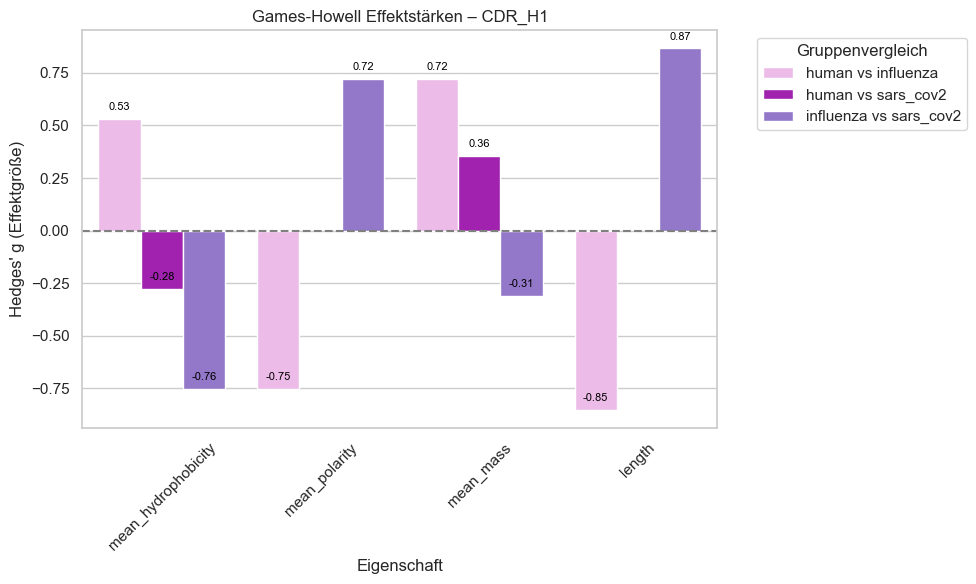

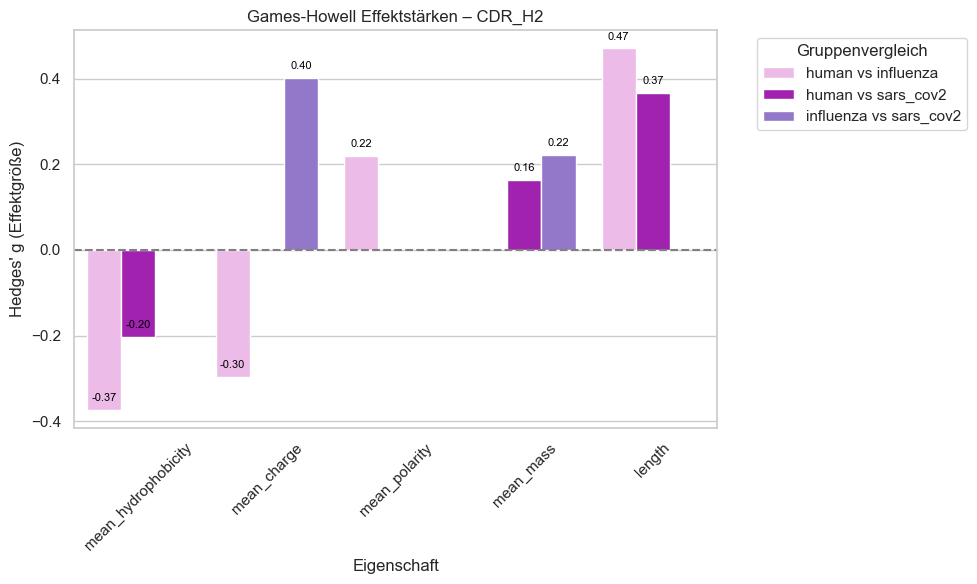

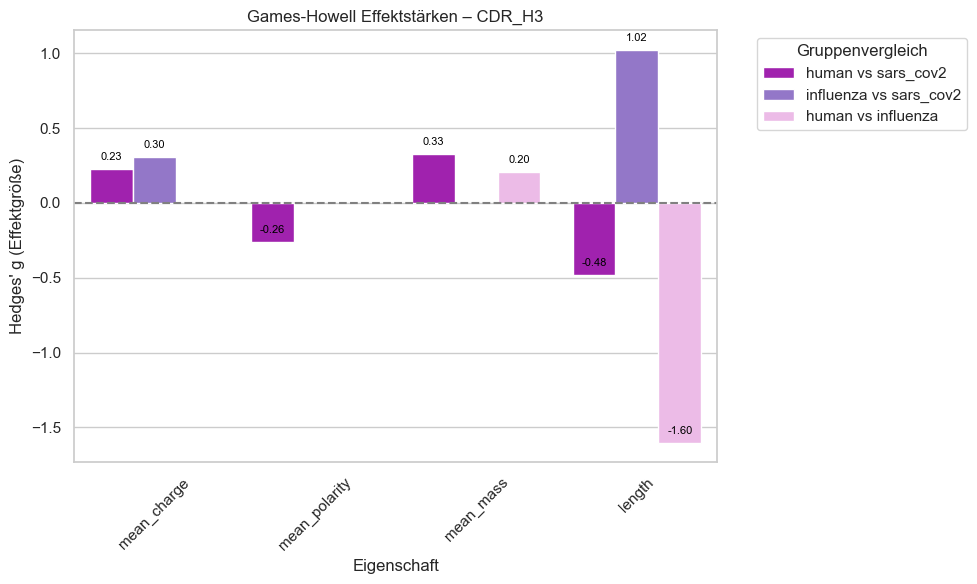

In [119]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Daten laden
df = pd.read_csv("games_howell_results.tsv", sep="\t")

# Nur signifikante Ergebnisse
df_sig = df[df["pval"] < 0.05].copy()
df_sig["pair"] = df_sig["A"] + " vs " + df_sig["B"]
df_sig["region"] = df_sig["feature"].str.extract(r'(CDR_H\d|cdr_h\d)', expand=False)
df_sig["property"] = df_sig["feature"].str.replace(r'(CDR_H\d|cdr_h\d)_?', '', regex=True)

# Farbpalette für Gruppenvergleiche
custom_colors = {
    "human vs influenza": "#f4b3ee",
    "human vs sars_cov2": "#b30bc5",
    "influenza vs sars_cov2": "#8F6AD5"
}

# Regionen durchgehen
regions = ["CDR_H1", "CDR_H2", "CDR_H3"]

for region in regions:
    df_region = df_sig[df_sig["region"].str.lower() == region.lower()]
    if df_region.empty:
        continue

    plt.figure(figsize=(10, 6))
    ax = sns.barplot(data=df_region, x="property", y="hedges", hue="pair", palette=custom_colors)

    # Effektgrößen als Zahlen beschriften
    for container in ax.containers:
        for bar in container:
            height = bar.get_height()
            if height != 0:
                ax.annotate(f"{height:.2f}",
                            xy=(bar.get_x() + bar.get_width() / 2, height),
                            xytext=(0, 5),
                            textcoords="offset points",
                            ha='center', va='bottom',
                            fontsize=8, color='black')

    plt.axhline(0, color="gray", linestyle="--")
    plt.title(f"Games-Howell Effektstärken – {region}")
    plt.ylabel("Hedges' g (Effektgröße)")
    plt.xlabel("Eigenschaft")
    plt.xticks(rotation=45)
    plt.legend(title="Gruppenvergleich", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


## Interpretation der Ergebnisse:
## ! es weden nur gruppen angezeigt die einen signifikanten p-Wert haben
#### - X-Achse: Eigenschaften 
#### - Y-Achse: Effektstärke (Hedges) → misst die Größe des Unterschieds zwischen Gruppen
#### => Wert > 0: Gruppe B hat im Mittel größere Werte als Gruppe A.
#### => Wert < 0: Gruppe A hat im Mittel größere Werte als Gruppe B.
#### => Wert ≈ 0: Kein oder nur kleiner Unterschied
---

## Verglecih der biophysikalischen Merkmale von CDR-H3, H2 und H3 zwischen den einzlennen Spezien 

- ANOVO:
    - Prüft, ob es einen signifikanten Unterschied im Mittelwert der Eigenschaft zwischen den drei Gruppen gibt

!! ANOVA sagt nicht, wo genau der Unterschied liegt – nur, ob überhaupt einer da ist

     => Gibt den p-Wert aus dem ANOVA-Test aus
     
→ Ein Wert kleiner als 0.05 gilt oft als signifikant


## Erklärung Code für ANOVA Test:

##  Zeile 1

```python
import pandas as pd
```

* `import`: holt ein externes Modul in dein Python-Skript.
* `pandas`: eine sehr verbreitete Bibliothek zur Datenanalyse und Tabellenverarbeitung.
* `as pd`: wir geben `pandas` den Kurznamen `pd`, damit wir später schneller darauf zugreifen können.

> Ab jetzt verwenden wir `pd` immer, wenn wir `pandas`-Funktionen benutzen (z. B. `pd.read_csv`, `pd.DataFrame` usw.).

---

##  Zeile 2

```python
from scipy.stats import f_oneway
```

* `from scipy.stats`: importiert ein Untermodul der `scipy`-Bibliothek, nämlich das Statistikmodul.
* `f_oneway`: ist die Funktion für den **einseitigen Varianzanalysentest (ANOVA)**.
  Sie vergleicht **mehr als zwei Gruppen** auf Mittelwertsunterschiede.

>  Beispiel: Wenn du drei Gruppen hast (z. B. human, sars, influenza), prüft `f_oneway`, ob mindestens eine davon signifikant anders ist als die anderen.

---

##  Zeile 5

```python
df = pd.read_csv("all_data.tsv", sep="\t")
```

* `df`: der Name der DataFrame-Variable, also der Tabelle mit den Daten.
* `pd.read_csv`: liest eine Datei im CSV/TSV-Format ein.
* `"all_data.tsv"`: der Dateiname. Das ist eine **Tabulator-separierte** Datei (TSV = Tab-Separated Values).
* `sep="\t"`: gibt an, dass die Spalten **durch Tabulatoren** getrennt sind (`\t` = Tab-Zeichen).

>  Jetzt enthält `df` alle Spalten aus deiner Datei: wahrscheinlich Spalten wie `"source"`, `"CDR_H3_mean_mass"`, `"CDR_H3_mean_charge"` usw.

---

##  Zeile 8

```python
properties = ['mean_hydrophobicity', 'mean_charge', 'mean_polarity', 'mean_mass'] 
```

* `properties`: eine Liste mit den Eigenschaften, die du analysieren möchtest.
* Diese Eigenschaften beziehen sich auf bestimmte chemisch-biologische Merkmale von Antikörpern (hier: CDR\_H3-Regionen).

>  Das Ziel ist, **jede dieser Eigenschaften** bei verschiedenen Herkunftsgruppen (human, sars\_cov2, influenza) zu vergleichen.

---

##  Zeile 11: Beginn der Schleife

```python
for prop in properties:
```

* `for`: startet eine Schleife.
* `prop`: eine temporäre Variable, die pro Schleifendurchlauf **ein Element** aus der Liste `properties` annimmt.
* Wir durchlaufen also: `mean_hydrophobicity`, `mean_charge`, `mean_polarity`, `mean_mass`.

>  Die Schleife wird **4× durchlaufen**, jeweils für eine dieser Eigenschaften.

---

##  Zeile 12

```python
column = f'CDR_H3_{prop}'
```

* `f'CDR_H3_{prop}'`: das ist ein sogenannter **f-String** (formatierter String).
* `{prop}` wird dynamisch durch den aktuellen Schleifenwert ersetzt.

  * z. B. in Durchlauf 1 → `"CDR_H3_mean_hydrophobicity"`
* Das ergibt den Spaltennamen, den wir in der Datei `df` suchen.

> Ziel: Zugriff auf die jeweilige Spalte mit Daten für eine bestimmte chemische Eigenschaft der CDR\_H3-Region.

---

##  Zeilen 14–16

```python
group_human = df[df["source"] == "human"][column].dropna()
group_sars = df[df["source"] == "sars_cov2"][column].dropna()
group_influenza = df[df["source"] == "influenza"][column].dropna()
```

Diese drei Zeilen extrahieren die Daten für jede Gruppe:

### Schrittweise Erklärung (für jede Zeile):

* `df["source"] == "human"`: erstellt eine **Maske** (True/False), die nur Zeilen mit `"source" == "human"` auswählt.
* `df[...]`: wendet diese Maske an → filtert nur die human-Zeilen.
* `[column]`: wählt dann aus diesen Zeilen **nur die relevante Spalte** (z. B. `"CDR_H3_mean_polarity"`).
* `.dropna()`: entfernt fehlende Werte (NaNs), damit die Statistik funktioniert.

>  Ergebnis: drei saubere Gruppen mit Werten zu z. B. `"CDR_H3_mean_charge"`.

---

## Zeile 18

```python
f_stat, p_val = f_oneway(group_human, group_sars, group_influenza)
```

* Hier rufen wir den **ANOVA-Test** auf.
* `f_oneway(...)`: testet, ob es **einen Unterschied im Mittelwert** zwischen den drei Gruppen gibt.
* Übergabe: `group_human`, `group_sars`, `group_influenza` (jeweils ein Array von Zahlen).
* Rückgabe:

  * `f_stat`: der berechnete F-Wert (wie viel größer die Streuung **zwischen** Gruppen im Vergleich zur Streuung **innerhalb** Gruppen ist).
  * `p_val`: der **p-Wert** – sagt, ob der Unterschied **statistisch signifikant** ist.

>  Wenn `p_val < 0.05`, dann ist mindestens eine Gruppe signifikant verschieden!

---

## Zeile 21

```python
print(f"{column} – ANOVA p-value: {p_val:.4f}")
```

* `print(...)`: zeigt das Ergebnis in der Konsole.
* `f"{column} – ANOVA p-value: {p_val:.4f}"`: ein formatierter String:

  * `{column}`: zeigt z. B. `"CDR_H3_mean_mass"`
  * `{p_val:.4f}`: formatiert den p-Wert auf **4 Nachkommastellen** (z. B. `0.0001`)

---




### CDR H3

### ANOVA

In [71]:
import pandas as pd
from scipy.stats import f_oneway # Function for the one-way analysis of variance test (ANOVA)

# Load the dataset
df = pd.read_csv("all_data.tsv", sep="\t")

# Properties to be analyzed
properties = ['mean_hydrophobicity', 'mean_charge', 'mean_polarity', 'mean_mass'] # list of the properties we want to analyze

# Perform ANOVA test for each property
for prop in properties: # start loop 
    column = f'CDR_H3_{prop}'# f-String
    
    # Extract groups
    group_human = df[df["source"] == "human"][column].dropna()
    group_sars = df[df["source"] == "sars_cov2"][column].dropna()
    group_influenza = df[df["source"] == "influenza"][column].dropna()
    
    # ANOVA test
    f_stat, p_val = f_oneway(group_human, group_sars, group_influenza)
    
    # Print result
    print(f"{column} – ANOVA p-value: {p_val:.4f}")


CDR_H3_mean_hydrophobicity – ANOVA p-value: 0.1955
CDR_H3_mean_charge – ANOVA p-value: 0.0000
CDR_H3_mean_polarity – ANOVA p-value: 0.0000
CDR_H3_mean_mass – ANOVA p-value: 0.0000


### to be investigated further : 

#### - CDR_H3_mean_charge, 
#### - CDR_H3_mean_polarity, 
#### - CDR_H3_mean_mass
--------

## Erklärung Tukey HSD (Honest Significant Difference) Test Code 


```python
from statsmodels.stats.multicomp import pairwise_tukeyhsd
```

**Was passiert hier?**
Du importierst die Funktion `pairwise_tukeyhsd` aus dem Modul `statsmodels.stats.multicomp`.

Diese Funktion wird für den **Tukey-HSD-Test** verwendet – ein **post-hoc-Test**, der nach einer ANOVA prüft, **welche Gruppen sich signifikant unterscheiden**.

---

```python
# Daten laden
df = pd.read_csv("all_data.tsv", sep="\t")
```

Die Datei `all_data.tsv` wird mit **Tabulator-getrennten Werten** (`sep="\t"`) eingelesen.

---

```python
# Spalte für Analyse
column = 'CDR_H3_mean_polarity'
```

Du legst fest, **welche Variable** du untersuchen willst – hier ist es:


---

```python
# Nur gültige Werte
df_clean = df[[column, "source"]].dropna()
```

Du erstellst eine neue Tabelle (`df_clean`) mit nur zwei Spalten:

1. Die **analysierte Eigenschaft** 
2. Die **Gruppierung** (`source`) – also: `human`, `sars_cov2`, `influenza`

Wichtig: Zeilen mit fehlenden Werten (`NaN`) werden entfernt → `dropna()`

---

```python
# Tukey-HSD-Test
tukey_result = pairwise_tukeyhsd(
    endog=df_clean[column],      # abhängige Variable (Werte)
    groups=df_clean["source"],   # Gruppierung (z. B. human/sars/influenza)
    alpha=0.05                   # Signifikanzniveau
)
```


* `endog=` → die **Messwerte**, also die `CDR_H3_mean_polarity` pro Antikörper
* `groups=` → die **Kategorien**, nach denen gruppiert wird (`source`)
* `alpha=0.05` → Signifikanzniveau = 5 %


---

```python
# Ergebnis anzeigen
print(tukey_result)
```


---



### CDR_H3_mean_polarity 
### Tukey HSD

In [72]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Daten laden
df = pd.read_csv("all_data.tsv", sep="\t")

# Spalte für Analyse
column = 'CDR_H3_mean_polarity'

# Nur gültige Werte
df_clean = df[[column, "source"]].dropna()

# Tukey-HSD-Test
tukey_result = pairwise_tukeyhsd(
    endog=df_clean[column],      # abhängige Variable (Werte)
    groups=df_clean["source"],   # Gruppierung (z. B. human/sars/influenza)
    alpha=0.05                   # Signifikanzniveau
)

# Ergebnis anzeigen
print(tukey_result)


   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
  group1    group2  meandiff p-adj   lower  upper  reject
---------------------------------------------------------
    human influenza   0.0914 0.0981 -0.0126 0.1954  False
    human sars_cov2    0.146    0.0   0.083  0.209   True
influenza sars_cov2   0.0546 0.4241 -0.0478  0.157  False
---------------------------------------------------------


## Erklärung code für Tukey Plot:



```python
import matplotlib.pyplot as plt
```
 **Import von Matplotlib**
Du importierst das `pyplot`-Modul von `matplotlib`, um später **Diagramme** zu zeichnen – insbesondere **Konfidenzintervall-Plots**.

---

```python
# Daten laden
df = pd.read_csv("all_data.tsv", sep="\t")
```
 **Einlesen der Daten**
Die Datei `all_data.tsv` wird geladen und als DataFrame `df` gespeichert.

* `sep="\t"` bedeutet: Die Datei ist **tabulatorgetrennt (TSV)**
* Ergebnis: `df` enthält vermutlich Spalten wie `"source"` und `"CDR_H3_mean_polarity"`.

---

```python
column = 'CDR_H3_mean_polarity'  
```
 **Spalte festlegen**
Du legst die zu untersuchende Variable fest:
→ die **mittlere Polarität** der **CDR-H3**-Region.

---

```python
# Nur gültige Werte auswählen
df_clean = df[[column, "source"]].dropna()
```
 **Daten bereinigen**
Du wählst nur die Spalten:

* die zu analysierende Messung (`column`)
* die Gruppenzugehörigkeit (`source`)

`dropna()` entfernt alle Zeilen mit fehlenden Werten (NaNs) → wichtig für Statistik!

---

```python
# Tukey-HSD-Test durchführen
tukey = pairwise_tukeyhsd(endog=df_clean[column], groups=df_clean["source"], alpha=0.05)
```
 **Tukey-HSD-Test (Post-hoc-Analyse)**
Du führst den **Tukey-Test** durch, um alle Paarvergleiche der Gruppen zu analysieren:

* `endog`: die abhängige Variable (z. B. Polarität)
* `groups`: Gruppierung nach `"source"` (human, sars\_cov2, influenza)
* `alpha=0.05`: Signifikanzniveau (5 %)

Der Test prüft für **alle Kombinationen** der Gruppen (z. B. human vs. sars), ob deren Mittelwerte **signifikant unterschiedlich** sind.

---

```python
summary_df = pd.DataFrame(data=tukey.summary().data[1:], columns=tukey.summary().data[0])
```

 **Ergebnisse in DataFrame umwandeln**

* `tukey.summary()` gibt eine tabellarische Zusammenfassung zurück.
* `data[0]`: Spaltenüberschriften (z. B. group1, group2, meandiff…)
* `data[1:]`: die Zeilendaten der Tests
 Daraus wird ein neuer DataFrame `summary_df` gebaut.

---

```python
# Datentypen korrekt setzen
summary_df["meandiff"] = summary_df["meandiff"].astype(float)
summary_df["lower"] = summary_df["lower"].astype(float)
summary_df["upper"] = summary_df["upper"].astype(float)
summary_df["reject"] = summary_df["reject"].astype(bool)
```

 **Sicherheit bei Datentypen**
Du wandelst die wichtigsten Spalten in **richtige Typen** um:

* `meandiff`: Mittelwertdifferenz zwischen den Gruppen
* `lower`, `upper`: untere und obere Grenze des 95 %-Konfidenzintervalls
* `reject`: `True`, wenn der Unterschied signifikant ist (p < 0.05)

---

```python
# Farbzuweisung NUR nach Signifikanz
def get_color(row):
    return "tab:pink" if row["reject"] else "gray"
```

**Farbfunktion**
Du definierst eine Funktion, die Zeilen **pink einfärbt**, wenn ein **signifikanter Unterschied vorliegt**, sonst grau.

---

```python
summary_df["color"] = summary_df.apply(get_color, axis=1)
```

 **Farbinformation anwenden**
Die Farbfunktion wird auf jede Zeile angewendet → Neue Spalte `color` mit `"tab:pink"` oder `"gray"` je nach Signifikanz.

---

```python
# Plot erstellen
plt.figure(figsize=(8, 5))
```

 **Start der Grafik**
Initialisiert die Plotfläche mit einer Breite von 8 und Höhe von 5 Zoll.

---

```python
for i, row in summary_df.iterrows():
    plt.hlines(y=i, xmin=row["lower"], xmax=row["upper"], color=row["color"], lw=3)
    plt.plot(row["meandiff"], i, 'o', color=row["color"])
```

**Konfidenzintervalle und Mittelwertpunkte plotten**

* `hlines`: zeichnet horizontale Linien von `lower` bis `upper` → das Konfidenzintervall
* `plot`: markiert den Mittelwert (meandiff) als Punkt
* `y=i`: jede Vergleichsgruppe erhält eigene Y-Position

---

```python
plt.axvline(x=0, color="black", linestyle="--")
```

 **Referenzlinie bei Null**
Zeigt, ob das Konfidenzintervall **über oder unter 0 liegt** – wichtig für Signifikanzinterpretation!

---

```python
plt.yticks(range(len(summary_df)), [
    f"{row['group1']} – {row['group2']}" for _, row in summary_df.iterrows()
])
```

**Y-Achsenbeschriftung**
Zeigt für jede Zeile den Gruppenvergleich an, z. B.:

* `human – sars_cov2`
* `human – influenza`
* `sars_cov2 – influenza`

---

```python
plt.title(f"Tukey-HSD 95% CI – {column}")
plt.xlabel("Mean Difference")
plt.ylabel("Group Comparison")
plt.tight_layout()
plt.show()
```

 **Beschriftung und Darstellung**

* Titel: zeigt, was analysiert wurde
* X-Achse: Differenz der Mittelwerte
* Y-Achse: welche Gruppen wurden verglichen
* `tight_layout()`: optimiert Platznutzung
* `show()`: zeigt den fertigen Plot

---



### Visualisierung der Gruppenunterschiede mit dem Tukey-HSD-Test

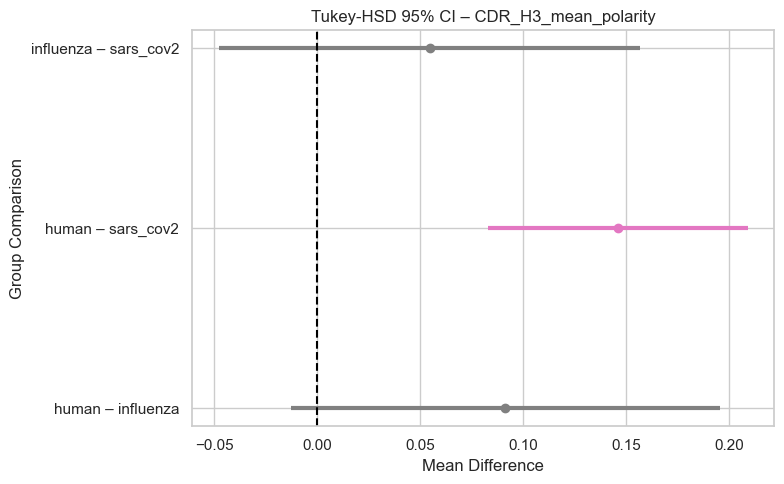

In [73]:
import matplotlib.pyplot as plt

# Daten laden
df = pd.read_csv("all_data.tsv", sep="\t")
column = 'CDR_H3_mean_polarity'  

# Nur gültige Werte auswählen
df_clean = df[[column, "source"]].dropna()

# Tukey-HSD-Test durchführen
tukey = pairwise_tukeyhsd(endog=df_clean[column], groups=df_clean["source"], alpha=0.05)
summary_df = pd.DataFrame(data=tukey.summary().data[1:], columns=tukey.summary().data[0])

# Datentypen korrekt setzen
summary_df["meandiff"] = summary_df["meandiff"].astype(float)
summary_df["lower"] = summary_df["lower"].astype(float)
summary_df["upper"] = summary_df["upper"].astype(float)
summary_df["reject"] = summary_df["reject"].astype(bool)

# Farbzuweisung NUR nach Signifikanz
def get_color(row):
    return "tab:pink" if row["reject"] else "gray"

summary_df["color"] = summary_df.apply(get_color, axis=1)

# Plot erstellen
plt.figure(figsize=(8, 5))
for i, row in summary_df.iterrows():
    plt.hlines(y=i, xmin=row["lower"], xmax=row["upper"], color=row["color"], lw=3)
    plt.plot(row["meandiff"], i, 'o', color=row["color"])

plt.axvline(x=0, color="black", linestyle="--")
plt.yticks(range(len(summary_df)), [
    f"{row['group1']} – {row['group2']}" for _, row in summary_df.iterrows()
])
plt.title(f"Tukey-HSD 95% CI – {column}")
plt.xlabel("Mean Difference")
plt.ylabel("Group Comparison")
plt.tight_layout()
plt.show()


### Interpretation:
#### CDR-H3 von humanen-Antikörper haben höhere Polarität im Schnitt
-----------

### CDR_H3_mean_charge
### Tukey HSD

In [74]:

# Daten laden
df = pd.read_csv("all_data.tsv", sep="\t")

# Spalte für Analyse
column = 'CDR_H3_mean_charge'

# Nur gültige Werte
df_clean = df[[column, "source"]].dropna()

# Tukey-HSD-Test
tukey_result = pairwise_tukeyhsd(
    endog=df_clean[column],      # abhängige Variable (Werte)
    groups=df_clean["source"],   # Gruppierung (z. B. human/sars/influenza)
    alpha=0.05                   # Signifikanzniveau
)

# Ergebnis anzeigen
print(tukey_result)


   Multiple Comparison of Means - Tukey HSD, FWER=0.05    
  group1    group2  meandiff p-adj   lower   upper  reject
----------------------------------------------------------
    human influenza   0.0068 0.7368 -0.0146  0.0281  False
    human sars_cov2  -0.0266    0.0 -0.0396 -0.0137   True
influenza sars_cov2  -0.0334 0.0006 -0.0544 -0.0124   True
----------------------------------------------------------


### Visualisierung der Gruppenunterschiede mit dem Tukey-HSD-Test

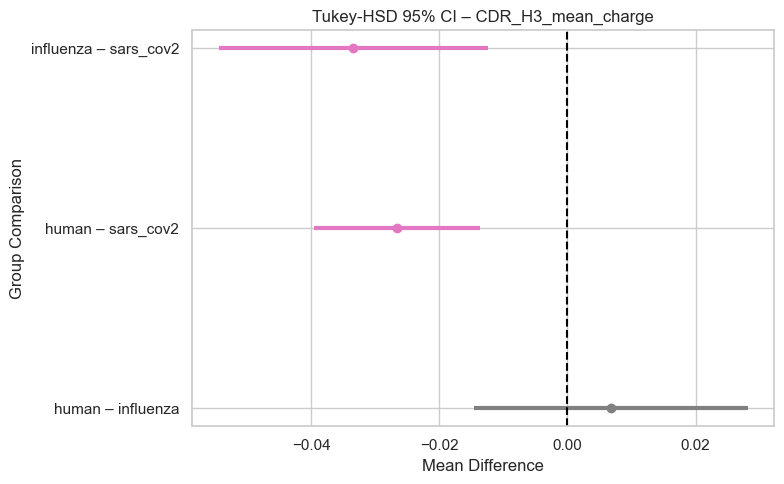

In [75]:


# Daten laden
df = pd.read_csv("all_data.tsv", sep="\t")
column = 'CDR_H3_mean_charge'  

# Nur gültige Werte auswählen
df_clean = df[[column, "source"]].dropna()

# Tukey-HSD-Test durchführen
tukey = pairwise_tukeyhsd(endog=df_clean[column], groups=df_clean["source"], alpha=0.05)
summary_df = pd.DataFrame(data=tukey.summary().data[1:], columns=tukey.summary().data[0])

# Datentypen korrekt setzen
summary_df["meandiff"] = summary_df["meandiff"].astype(float)
summary_df["lower"] = summary_df["lower"].astype(float)
summary_df["upper"] = summary_df["upper"].astype(float)
summary_df["reject"] = summary_df["reject"].astype(bool)

# Farbzuweisung NUR nach Signifikanz
def get_color(row):
    return "tab:pink" if row["reject"] else "gray"

summary_df["color"] = summary_df.apply(get_color, axis=1)

# Plot erstellen
plt.figure(figsize=(8, 5))
for i, row in summary_df.iterrows():
    plt.hlines(y=i, xmin=row["lower"], xmax=row["upper"], color=row["color"], lw=3)
    plt.plot(row["meandiff"], i, 'o', color=row["color"])

plt.axvline(x=0, color="black", linestyle="--")
plt.yticks(range(len(summary_df)), [
    f"{row['group1']} – {row['group2']}" for _, row in summary_df.iterrows()
])
plt.title(f"Tukey-HSD 95% CI – {column}")
plt.xlabel("Mean Difference")
plt.ylabel("Group Comparison")
plt.tight_layout()
plt.show()


### Interpretation:
#### - mittlere Ladung in der CDR-H3-Region ist bei SARS-CoV-2-Antikörpern höher als bei humanen Antikörpern
#### - mittlere Ladung in CDR-H3-Region ist bei SARS-CoV-2-Antikörper höher als bei Influenza
#### => Antikörper gegen SARS-CoV-2 zeigen eine signifikant höhere mittlere Ladung in der CDR-H3-Region als Antikörper gegen Influenza oder aus der humanen Kontrollgruppe
------------

### CDR_H3_mean_mass
### Tukey HSD

In [76]:


# Daten laden
df = pd.read_csv("all_data.tsv", sep="\t")

# Spalte für Analyse
column = 'CDR_H3_mean_mass'

# Nur gültige Werte
df_clean = df[[column, "source"]].dropna()

# Tukey-HSD-Test
tukey_result = pairwise_tukeyhsd(
    endog=df_clean[column],      # abhängige Variable (Werte)
    groups=df_clean["source"],   # Gruppierung (z. B. human/sars/influenza)
    alpha=0.05                   # Signifikanzniveau
)

# Ergebnis anzeigen
print(tukey_result)


   Multiple Comparison of Means - Tukey HSD, FWER=0.05    
  group1    group2  meandiff p-adj   lower   upper  reject
----------------------------------------------------------
    human influenza  -1.8956 0.0321 -3.6637 -0.1276   True
    human sars_cov2  -3.1731    0.0 -4.2437 -2.1026   True
influenza sars_cov2  -1.2775 0.1976 -3.0187  0.4637  False
----------------------------------------------------------


### Visualisierung der Gruppenunterschiede mit dem Tukey-HSD-Test

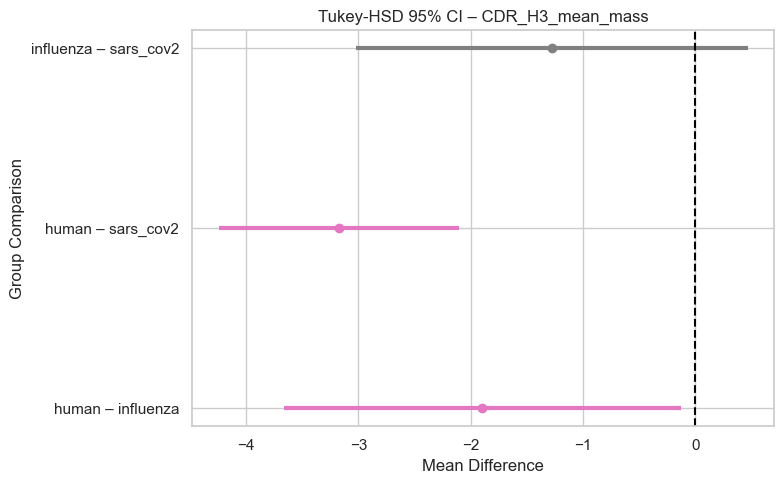

In [77]:


# Daten laden
df = pd.read_csv("all_data.tsv", sep="\t")
column = 'CDR_H3_mean_mass'  

# Nur gültige Werte auswählen
df_clean = df[[column, "source"]].dropna()

# Tukey-HSD-Test durchführen
tukey = pairwise_tukeyhsd(endog=df_clean[column], groups=df_clean["source"], alpha=0.05)
summary_df = pd.DataFrame(data=tukey.summary().data[1:], columns=tukey.summary().data[0])

# Datentypen korrekt setzen
summary_df["meandiff"] = summary_df["meandiff"].astype(float)
summary_df["lower"] = summary_df["lower"].astype(float)
summary_df["upper"] = summary_df["upper"].astype(float)
summary_df["reject"] = summary_df["reject"].astype(bool)

# Farbzuweisung NUR nach Signifikanz
def get_color(row):
    return "tab:pink" if row["reject"] else "gray"

summary_df["color"] = summary_df.apply(get_color, axis=1)

# Plot erstellen
plt.figure(figsize=(8, 5))
for i, row in summary_df.iterrows():
    plt.hlines(y=i, xmin=row["lower"], xmax=row["upper"], color=row["color"], lw=3)
    plt.plot(row["meandiff"], i, 'o', color=row["color"])

plt.axvline(x=0, color="black", linestyle="--")
plt.yticks(range(len(summary_df)), [
    f"{row['group1']} – {row['group2']}" for _, row in summary_df.iterrows()
])
plt.title(f"Tukey-HSD 95% CI – {column}")
plt.xlabel("Mean Difference")
plt.ylabel("Group Comparison")
plt.tight_layout()
plt.show()


### Interpretation:
#### - Die mittlere Aminosäuremasse in CDR-H3 ist bei SARS-CoV-2-Antikörpern höher als bei humanen Antikörpern

--------


#### Erklärurng Plot

= Visualisierung **Tukey-HSD-Analyse** 

= **graphische Darstellung der Ergebnisse des Tukey-HSD-Tests** für die Variable `CDR_H3_mean_polarity`.

### Achsen & Bedeutung:

* **Y-Achse:** Paarweise Gruppenvergleiche 
* **X-Achse:** Mittelwertsdifferenz zwischen diesen Gruppen
* **Horizontale Linien:** 95 %-Konfidenzintervalle der Differenz
* **Punkte:** Der geschätzte Mittelwertsunterschied
* **Vertikale gestrichelte Linie:** Null-Linie (kein Unterschied)

### Farben:

* ** Rot:** Statistisch **signifikanter Unterschied** (p-Wert < 0.05)
* ** Grau:** Kein signifikanter Unterschied (p-Wert ≥ 0.05)

# ! Tukey-HSD-Test = Tukey’s Honest Significant Difference (HSD)

### = Post-hoc-Test
    = welche Gruppenpaare unterscheiden sich signifikant voneinander – welche Mittelwerte sind tatsächlich verschieden 

#### Verwendung

- bei signifikanten Unterschied: bei ANOVA p-Wert < 0,05

- bei mehrere Gruppen

- Um genau zu sehen, zwischen welchen Gruppen der Unterschied liegt

#### Wie funktioniert der Test:

- Differenz der Mittelwerte 

- Standardfehler der Differenz (berücksichtigt die Streuung innerhalb der Gruppen und die Anzahl der Stichproben (je größer n, desto genauer))

- Vergleich mit kritischem Wert
= Der kritische Wert stammt aus der studentisierten Range-Verteilung („q-Verteilung“) und hängt ab von:

- Anzahl der Gruppen k
- Anzahl aller Stichproben
- Signifikanzniveau α (meist 0.05)

#### Bedeutung

- meandiff: Mittelwertsunterschied

- p-adj: Adjustierter p-Wert

- lower / upper: Konfidenzintervall

- reject: True = signifikanter Unterschied
------------









### CDR H2
### ANOVA one way

In [78]:
# Load the dataset
df = pd.read_csv("all_data.tsv", sep="\t")

# Properties to be analyzed
properties = ['mean_hydrophobicity', 'mean_charge', 'mean_polarity', 'mean_mass'] 

# Perform ANOVA test for each property (CDR_H2)
for prop in properties:
    column = f'CDR_H2_{prop}'
    
    # Extract groups
    group_human = df[df["source"] == "human"][column].dropna()
    group_sars = df[df["source"] == "sars_cov2"][column].dropna()
    group_influenza = df[df["source"] == "influenza"][column].dropna()
    
    # ANOVA test
    f_stat, p_val = f_oneway(group_human, group_sars, group_influenza)
    
    # Print result
    print(f"{column} – ANOVA p-value: {p_val:.4f}")


CDR_H2_mean_hydrophobicity – ANOVA p-value: 0.0000
CDR_H2_mean_charge – ANOVA p-value: 0.0000
CDR_H2_mean_polarity – ANOVA p-value: 0.0241
CDR_H2_mean_mass – ANOVA p-value: 0.0007


### to be investigated further : 

#### - CDR_H2_mean_hydrophobicity
#### - CDR_H2_mean_charge
#### - CDR_H2_mean_mass
------

### CDR_H2_mean_hydrophobicity
### Tukey HSD

In [79]:
# Daten laden
df = pd.read_csv("all_data.tsv", sep="\t")

# Spalte für Analyse
column = 'CDR_H2_mean_hydrophobicity'

# Nur gültige Werte
df_clean = df[[column, "source"]].dropna()

# Tukey-HSD-Test
tukey_result = pairwise_tukeyhsd(
    endog=df_clean[column],      # abhängige Variable (Werte)
    groups=df_clean["source"],   # Gruppierung (z. B. human/sars/influenza)
    alpha=0.05                   # Signifikanzniveau
)

# Ergebnis anzeigen
print(tukey_result)


   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
  group1    group2  meandiff p-adj   lower  upper  reject
---------------------------------------------------------
    human influenza   0.3527 0.0001  0.1555 0.5498   True
    human sars_cov2   0.2116 0.0001  0.0922 0.3309   True
influenza sars_cov2  -0.1411 0.2035 -0.3353  0.053  False
---------------------------------------------------------


### Visualisierung der Gruppenunterschiede mit dem Tukey-HSD-Test

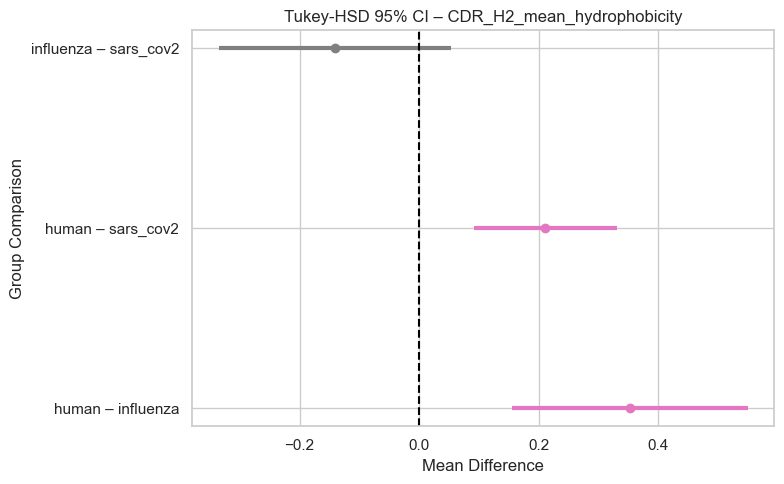

In [80]:
# Daten laden
df = pd.read_csv("all_data.tsv", sep="\t")
column = 'CDR_H2_mean_hydrophobicity'  

# Nur gültige Werte auswählen
df_clean = df[[column, "source"]].dropna()

# Tukey-HSD-Test durchführen
tukey = pairwise_tukeyhsd(endog=df_clean[column], groups=df_clean["source"], alpha=0.05)
summary_df = pd.DataFrame(data=tukey.summary().data[1:], columns=tukey.summary().data[0])

# Datentypen korrekt setzen
summary_df["meandiff"] = summary_df["meandiff"].astype(float)
summary_df["lower"] = summary_df["lower"].astype(float)
summary_df["upper"] = summary_df["upper"].astype(float)
summary_df["reject"] = summary_df["reject"].astype(bool)

# Farbzuweisung NUR nach Signifikanz
def get_color(row):
    return "tab:pink" if row["reject"] else "gray"

summary_df["color"] = summary_df.apply(get_color, axis=1)

# Plot erstellen
plt.figure(figsize=(8, 5))
for i, row in summary_df.iterrows():
    plt.hlines(y=i, xmin=row["lower"], xmax=row["upper"], color=row["color"], lw=3)
    plt.plot(row["meandiff"], i, 'o', color=row["color"])

plt.axvline(x=0, color="black", linestyle="--")
plt.yticks(range(len(summary_df)), [
    f"{row['group1']} – {row['group2']}" for _, row in summary_df.iterrows()
])
plt.title(f"Tukey-HSD 95% CI – {column}")
plt.xlabel("Mean Difference")
plt.ylabel("Group Comparison")
plt.tight_layout()
plt.show()


### Interpretation:
#### Die CDR-H2-Regionen humaner Antikörper sind signifikant hydrophober als die von SARS-CoV-2- und Influenza-Antikörpern.
#### => deutet darauf hin, dass Antikörper gegen Viren eher weniger hydrophobe Sequenzmerkmale in der CDR-H2-Region aufweisen
-------------

### CDR_H2_mean_charge

In [81]:

# Daten laden
df = pd.read_csv("all_data.tsv", sep="\t")

# Spalte für Analyse
column = 'CDR_H2_mean_charge'

# Nur gültige Werte
df_clean = df[[column, "source"]].dropna()

# Tukey-HSD-Test
tukey_result = pairwise_tukeyhsd(
    endog=df_clean[column],      # abhängige Variable (Werte)
    groups=df_clean["source"],   # Gruppierung (z. B. human/sars/influenza)
    alpha=0.05                   # Signifikanzniveau
)

# Ergebnis anzeigen
print(tukey_result)

   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
  group1    group2  meandiff p-adj   lower  upper  reject
---------------------------------------------------------
    human influenza   0.0539 0.0004  0.0207 0.0871   True
    human sars_cov2  -0.0158 0.1556 -0.0359 0.0043  False
influenza sars_cov2  -0.0697    0.0 -0.1024 -0.037   True
---------------------------------------------------------


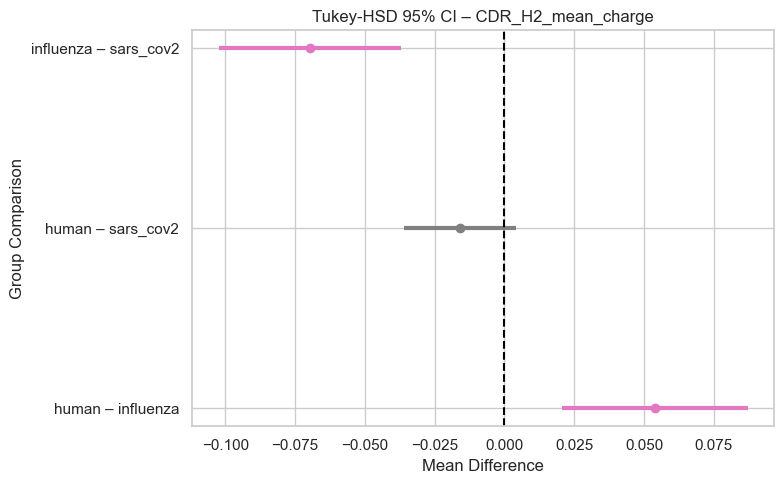

In [82]:
# Daten laden
df = pd.read_csv("all_data.tsv", sep="\t")
column = 'CDR_H2_mean_charge'  

# Nur gültige Werte auswählen
df_clean = df[[column, "source"]].dropna()

# Tukey-HSD-Test durchführen
tukey = pairwise_tukeyhsd(endog=df_clean[column], groups=df_clean["source"], alpha=0.05)
summary_df = pd.DataFrame(data=tukey.summary().data[1:], columns=tukey.summary().data[0])

# Datentypen korrekt setzen
summary_df["meandiff"] = summary_df["meandiff"].astype(float)
summary_df["lower"] = summary_df["lower"].astype(float)
summary_df["upper"] = summary_df["upper"].astype(float)
summary_df["reject"] = summary_df["reject"].astype(bool)

# Farbzuweisung NUR nach Signifikanz
def get_color(row):
    return "tab:pink" if row["reject"] else "gray"

summary_df["color"] = summary_df.apply(get_color, axis=1)

# Plot erstellen
plt.figure(figsize=(8, 5))
for i, row in summary_df.iterrows():
    plt.hlines(y=i, xmin=row["lower"], xmax=row["upper"], color=row["color"], lw=3)
    plt.plot(row["meandiff"], i, 'o', color=row["color"])

plt.axvline(x=0, color="black", linestyle="--")
plt.yticks(range(len(summary_df)), [
    f"{row['group1']} – {row['group2']}" for _, row in summary_df.iterrows()
])
plt.title(f"Tukey-HSD 95% CI – {column}")
plt.xlabel("Mean Difference")
plt.ylabel("Group Comparison")
plt.tight_layout()
plt.show()


#### Interpretation:
#### - sars höher als influenza 
#### - human höher als influenza 
------

### CDR_H2_mean_mass
### TUKEY 

In [83]:

# Daten laden
df = pd.read_csv("all_data.tsv", sep="\t")

# Spalte für Analyse
column = 'CDR_H2_mean_mass'

# Nur gültige Werte
df_clean = df[[column, "source"]].dropna()

# Tukey-HSD-Test
tukey_result = pairwise_tukeyhsd(
    endog=df_clean[column],      # abhängige Variable (Werte)
    groups=df_clean["source"],   # Gruppierung (z. B. human/sars/influenza)
    alpha=0.05                   # Signifikanzniveau
)

# Ergebnis anzeigen
print(tukey_result)



   Multiple Comparison of Means - Tukey HSD, FWER=0.05    
  group1    group2  meandiff p-adj   lower   upper  reject
----------------------------------------------------------
    human influenza   0.5581 0.8749 -2.0997  3.2158  False
    human sars_cov2   -2.336  0.002 -3.9452 -0.7268   True
influenza sars_cov2   -2.894 0.0259 -5.5114 -0.2767   True
----------------------------------------------------------


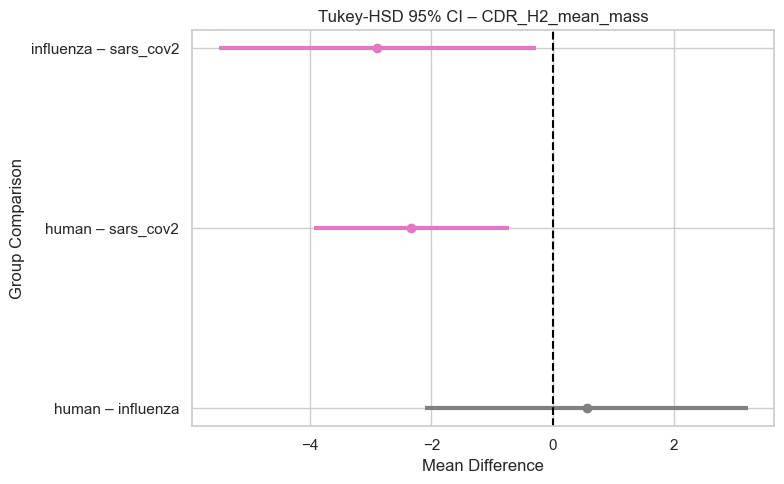

In [84]:
# Daten laden
df = pd.read_csv("all_data.tsv", sep="\t")
column = 'CDR_H2_mean_mass'  

# Nur gültige Werte auswählen
df_clean = df[[column, "source"]].dropna()

# Tukey-HSD-Test durchführen
tukey = pairwise_tukeyhsd(endog=df_clean[column], groups=df_clean["source"], alpha=0.05)
summary_df = pd.DataFrame(data=tukey.summary().data[1:], columns=tukey.summary().data[0])

# Datentypen korrekt setzen
summary_df["meandiff"] = summary_df["meandiff"].astype(float)
summary_df["lower"] = summary_df["lower"].astype(float)
summary_df["upper"] = summary_df["upper"].astype(float)
summary_df["reject"] = summary_df["reject"].astype(bool)

# Farbzuweisung NUR nach Signifikanz
def get_color(row):
    return "tab:pink" if row["reject"] else "gray"

summary_df["color"] = summary_df.apply(get_color, axis=1)

# Plot erstellen
plt.figure(figsize=(8, 5))
for i, row in summary_df.iterrows():
    plt.hlines(y=i, xmin=row["lower"], xmax=row["upper"], color=row["color"], lw=3)
    plt.plot(row["meandiff"], i, 'o', color=row["color"])

plt.axvline(x=0, color="black", linestyle="--")
plt.yticks(range(len(summary_df)), [
    f"{row['group1']} – {row['group2']}" for _, row in summary_df.iterrows()
])
plt.title(f"Tukey-HSD 95% CI – {column}")
plt.xlabel("Mean Difference")
plt.ylabel("Group Comparison")
plt.tight_layout()
plt.show()


### Interpretation:
### - Sars cov größere mittlere Masse als Human

### CDR H1

In [85]:
# Load the combined dataset
df = pd.read_csv("all_data.tsv", sep="\t")

# Properties to be analyzed
properties = ['mean_hydrophobicity', 'mean_charge', 'mean_polarity', 'mean_mass'] 

# Loop through each property (CDR_H1)
for prop in properties:
    column = f'CDR_H1_{prop}'
    
    # Extract groups
    group_human = df[df["source"] == "human"][column].dropna()
    group_sars = df[df["source"] == "sars_cov2"][column].dropna()
    group_influenza = df[df["source"] == "influenza"][column].dropna()
    
    # Perform ANOVA test
    f_stat, p_val = f_oneway(group_human, group_sars, group_influenza)
    
    # Print result
    print(f"{column} – ANOVA p-value: {p_val:.4f}")


CDR_H1_mean_hydrophobicity – ANOVA p-value: 0.0000
CDR_H1_mean_charge – ANOVA p-value: 0.1368
CDR_H1_mean_polarity – ANOVA p-value: 0.0000
CDR_H1_mean_mass – ANOVA p-value: 0.0000


### to be investigated further : 

#### - CDR_H1_mean_hydrophobicity, 
#### - CDR_H1_mean_polarity, 
#### - CDR_H1_mean_mass
------

### CDR_H1_mean_hydrophobicity
### Tukey HSD

In [86]:
# Daten laden
df = pd.read_csv("all_data.tsv", sep="\t")

# Spalte für Analyse
column = 'CDR_H1_mean_hydrophobicity'

# Nur gültige Werte
df_clean = df[[column, "source"]].dropna()

# Tukey-HSD-Test
tukey_result = pairwise_tukeyhsd(
    endog=df_clean[column],      # abhängige Variable (Werte)
    groups=df_clean["source"],   # Gruppierung (z. B. human/sars/influenza)
    alpha=0.05                   # Signifikanzniveau
)

# Ergebnis anzeigen
print(tukey_result)


   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
  group1    group2  meandiff p-adj  lower   upper  reject
---------------------------------------------------------
    human influenza  -0.2621   0.0 -0.3575 -0.1668   True
    human sars_cov2   0.1391   0.0  0.0814  0.1969   True
influenza sars_cov2   0.4013   0.0  0.3074  0.4952   True
---------------------------------------------------------


### Visualisierung der Gruppenunterschiede mit dem Tukey-HSD-Test

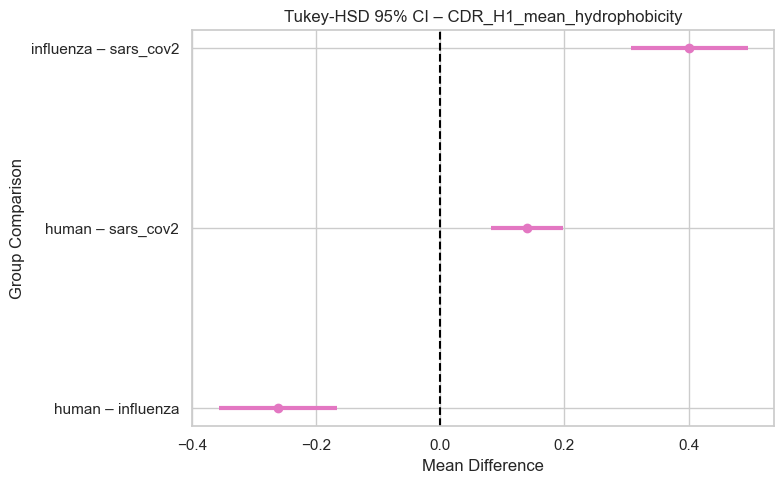

In [87]:
# Daten laden
df = pd.read_csv("all_data.tsv", sep="\t")
column = 'CDR_H1_mean_hydrophobicity'  

# Nur gültige Werte auswählen
df_clean = df[[column, "source"]].dropna()

# Tukey-HSD-Test durchführen
tukey = pairwise_tukeyhsd(endog=df_clean[column], groups=df_clean["source"], alpha=0.05)
summary_df = pd.DataFrame(data=tukey.summary().data[1:], columns=tukey.summary().data[0])

# Datentypen korrekt setzen
summary_df["meandiff"] = summary_df["meandiff"].astype(float)
summary_df["lower"] = summary_df["lower"].astype(float)
summary_df["upper"] = summary_df["upper"].astype(float)
summary_df["reject"] = summary_df["reject"].astype(bool)

# Farbzuweisung NUR nach Signifikanz
def get_color(row):
    return "tab:pink" if row["reject"] else "gray"

summary_df["color"] = summary_df.apply(get_color, axis=1)

# Plot erstellen
plt.figure(figsize=(8, 5))
for i, row in summary_df.iterrows():
    plt.hlines(y=i, xmin=row["lower"], xmax=row["upper"], color=row["color"], lw=3)
    plt.plot(row["meandiff"], i, 'o', color=row["color"])

plt.axvline(x=0, color="black", linestyle="--")
plt.yticks(range(len(summary_df)), [
    f"{row['group1']} – {row['group2']}" for _, row in summary_df.iterrows()
])
plt.title(f"Tukey-HSD 95% CI – {column}")
plt.xlabel("Mean Difference")
plt.ylabel("Group Comparison")
plt.tight_layout()
plt.show()


### Interpretation:
#### -  Influenza-Antikörper stärker hydrophob als SARS-CoV-2
#### -  Human-Antikörper haben höhere Hydrophobizität als SARS-CoV-2
#### - Human-Antikörper haben niedrigere Hydrophobizität als Influenza-Antikörper
#### => Alle drei Gruppenunterschiede in der mittleren Hydrophobizität der CDR-H1-Region sind signifikant. Influenza-Antikörper sind am hydrophobsten, SARS-CoV-2-Antikörper am wenigsten hydrophob, und humane Antikörper liegen dazwischen
----------

### CDR_H1_mean_polarity
### Tukey HSD

In [88]:
# Daten laden
df = pd.read_csv("all_data.tsv", sep="\t")

# Spalte für Analyse
column = 'CDR_H1_mean_polarity'

# Nur gültige Werte
df_clean = df[[column, "source"]].dropna()

# Tukey-HSD-Test
tukey_result = pairwise_tukeyhsd(
    endog=df_clean[column],      # abhängige Variable (Werte)
    groups=df_clean["source"],   # Gruppierung (z. B. human/sars/influenza)
    alpha=0.05                   # Signifikanzniveau
)

# Ergebnis anzeigen
print(tukey_result)


   Multiple Comparison of Means - Tukey HSD, FWER=0.05    
  group1    group2  meandiff p-adj   lower   upper  reject
----------------------------------------------------------
    human influenza   0.4239    0.0  0.3217  0.5261   True
    human sars_cov2    0.032 0.4466 -0.0299  0.0938  False
influenza sars_cov2   -0.392    0.0 -0.4926 -0.2913   True
----------------------------------------------------------


### Visualisierung der Gruppenunterschiede mit dem Tukey-HSD-Test

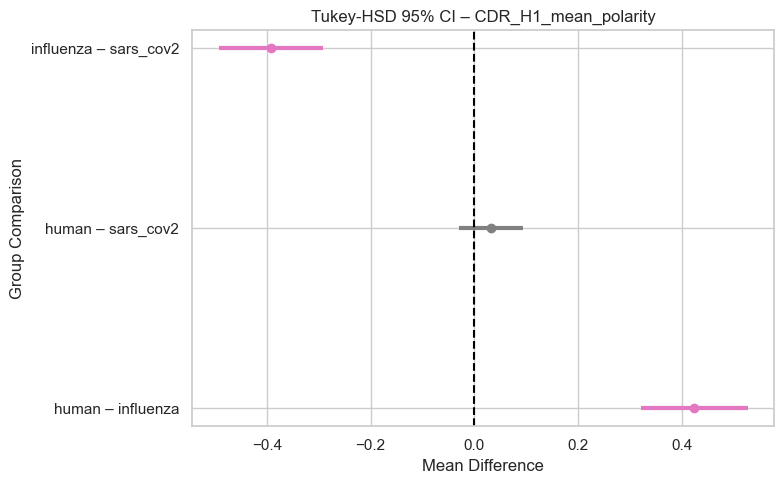

In [89]:
# Daten laden
df = pd.read_csv("all_data.tsv", sep="\t")
column = 'CDR_H1_mean_polarity'  

# Nur gültige Werte auswählen
df_clean = df[[column, "source"]].dropna()

# Tukey-HSD-Test durchführen
tukey = pairwise_tukeyhsd(endog=df_clean[column], groups=df_clean["source"], alpha=0.05)
summary_df = pd.DataFrame(data=tukey.summary().data[1:], columns=tukey.summary().data[0])

# Datentypen korrekt setzen
summary_df["meandiff"] = summary_df["meandiff"].astype(float)
summary_df["lower"] = summary_df["lower"].astype(float)
summary_df["upper"] = summary_df["upper"].astype(float)
summary_df["reject"] = summary_df["reject"].astype(bool)

# Farbzuweisung NUR nach Signifikanz
def get_color(row):
    return "tab:pink" if row["reject"] else "gray"

summary_df["color"] = summary_df.apply(get_color, axis=1)

# Plot erstellen
plt.figure(figsize=(8, 5))
for i, row in summary_df.iterrows():
    plt.hlines(y=i, xmin=row["lower"], xmax=row["upper"], color=row["color"], lw=3)
    plt.plot(row["meandiff"], i, 'o', color=row["color"])

plt.axvline(x=0, color="black", linestyle="--")
plt.yticks(range(len(summary_df)), [
    f"{row['group1']} – {row['group2']}" for _, row in summary_df.iterrows()
])
plt.title(f"Tukey-HSD 95% CI – {column}")
plt.xlabel("Mean Difference")
plt.ylabel("Group Comparison")
plt.tight_layout()
plt.show()


### Interpretation:
#### - Influenza-Antikörper haben niedrigere Polarität als SARS-CoV-2
#### - Human-Antikörper haben höhere Polarität als Influenza
--------

### CDR_H1_mean_mass
### Tukey HSD

In [90]:
# Daten laden
df = pd.read_csv("all_data.tsv", sep="\t")

# Spalte für Analyse
column = 'CDR_H1_mean_mass'

# Nur gültige Werte
df_clean = df[[column, "source"]].dropna()

# Tukey-HSD-Test
tukey_result = pairwise_tukeyhsd(
    endog=df_clean[column],      # abhängige Variable (Werte)
    groups=df_clean["source"],   # Gruppierung (z. B. human/sars/influenza)
    alpha=0.05                   # Signifikanzniveau
)

# Ergebnis anzeigen
print(tukey_result)


   Multiple Comparison of Means - Tukey HSD, FWER=0.05    
  group1    group2  meandiff p-adj   lower   upper  reject
----------------------------------------------------------
    human influenza  -6.6346    0.0  -8.452 -4.8172   True
    human sars_cov2  -3.3844    0.0 -4.4848  -2.284   True
influenza sars_cov2   3.2501 0.0001  1.4604  5.0399   True
----------------------------------------------------------


### Visualisierung der Gruppenunterschiede mit dem Tukey-HSD-Test

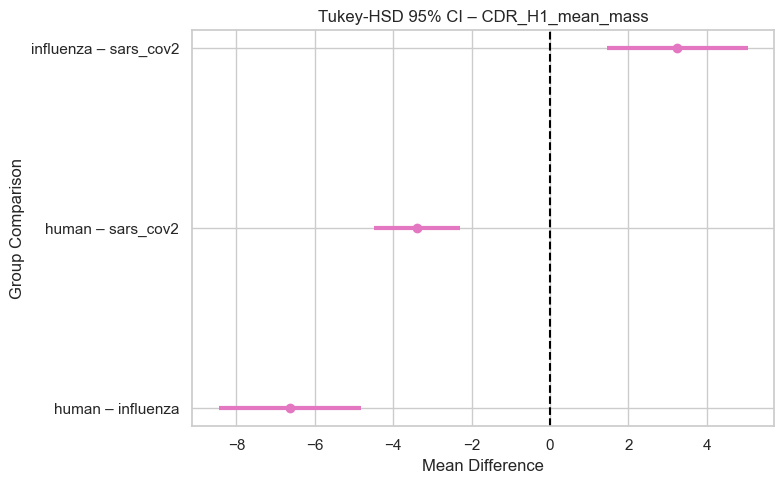

In [91]:
# Daten laden
df = pd.read_csv("all_data.tsv", sep="\t")
column = 'CDR_H1_mean_mass'  

# Nur gültige Werte auswählen
df_clean = df[[column, "source"]].dropna()

# Tukey-HSD-Test durchführen
tukey = pairwise_tukeyhsd(endog=df_clean[column], groups=df_clean["source"], alpha=0.05)
summary_df = pd.DataFrame(data=tukey.summary().data[1:], columns=tukey.summary().data[0])

# Datentypen korrekt setzen
summary_df["meandiff"] = summary_df["meandiff"].astype(float)
summary_df["lower"] = summary_df["lower"].astype(float)
summary_df["upper"] = summary_df["upper"].astype(float)
summary_df["reject"] = summary_df["reject"].astype(bool)

# Farbzuweisung NUR nach Signifikanz
def get_color(row):
    return "tab:pink" if row["reject"] else "gray"

summary_df["color"] = summary_df.apply(get_color, axis=1)

# Plot erstellen
plt.figure(figsize=(8, 5))
for i, row in summary_df.iterrows():
    plt.hlines(y=i, xmin=row["lower"], xmax=row["upper"], color=row["color"], lw=3)
    plt.plot(row["meandiff"], i, 'o', color=row["color"])

plt.axvline(x=0, color="black", linestyle="--")
plt.yticks(range(len(summary_df)), [
    f"{row['group1']} – {row['group2']}" for _, row in summary_df.iterrows()
])
plt.title(f"Tukey-HSD 95% CI – {column}")
plt.xlabel("Mean Difference")
plt.ylabel("Group Comparison")
plt.tight_layout()
plt.show()


### Interpretation:
#### - Die mittlere Masse bei human-Antikörpern ist signifikant geringer als bei SARS-CoV-2-Antikörpern
#### - Die mittlere Masse der CDR_H1-Region ist bei human-Antikörpern deutlich geringer als bei Influenza-Antikörpern
#### => Die mittlere Masse der CDR_H1-Region ist bei human-Antikörpern signifikant geringer als bei Antikörpern gegen Influenza oder SARS-CoV-2
-------

# Compare lengths

In [92]:
## ANOVA Test
# TSV-Datei einlesen
df = pd.read_csv("all_data.tsv", sep="\t")

# Liste der Längen-Spalten
length_columns = ['cdr_h1_length', 'cdr_h2_length', 'cdr_h3_length']

# Schleife über alle Regionen
for region in length_columns:
    group_human = df[df["source"] == "human"][region].dropna()
    group_sars = df[df["source"] == "sars_cov2"][region].dropna()
    group_influenza = df[df["source"] == "influenza"][region].dropna()
    
    f_stat, p_val = f_oneway(group_human, group_sars, group_influenza)
    print(f"{region} – ANOVA p-value: {p_val:.4f}")



cdr_h1_length – ANOVA p-value: 0.0000
cdr_h2_length – ANOVA p-value: 0.0000
cdr_h3_length – ANOVA p-value: 0.0000


### CDR H1

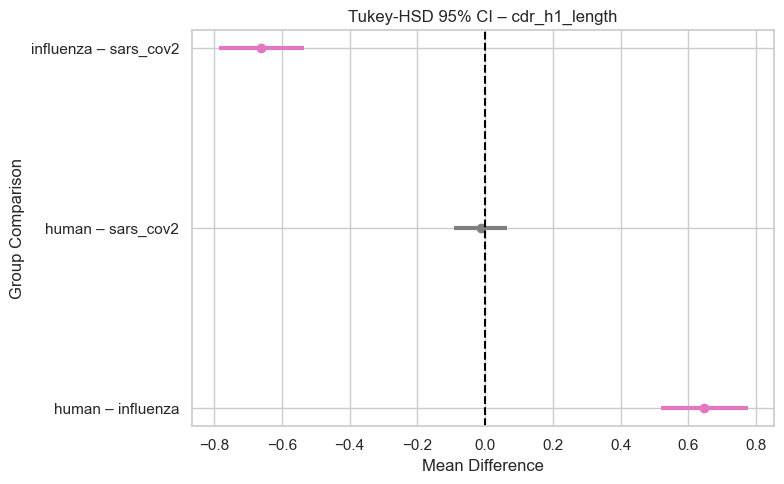

In [93]:
# Tukey-HSD für CDR-H1-Länge
column = "cdr_h1_length"
df_clean = df[[column, "source"]].dropna()

tukey = pairwise_tukeyhsd(endog=df_clean[column], groups=df_clean["source"], alpha=0.05)

# In DataFrame umwandeln
summary_df = pd.DataFrame(data=tukey.summary().data[1:], columns=tukey.summary().data[0])
summary_df["meandiff"] = summary_df["meandiff"].astype(float)
summary_df["lower"] = summary_df["lower"].astype(float)
summary_df["upper"] = summary_df["upper"].astype(float)
summary_df["reject"] = summary_df["reject"].astype(bool)
summary_df["color"] = summary_df["reject"].apply(lambda x: "tab:pink" if x else "gray")

# Plot
plt.figure(figsize=(8, 5))
for i, row in summary_df.iterrows():
    plt.hlines(y=i, xmin=row["lower"], xmax=row["upper"], color=row["color"], lw=3)
    plt.plot(row["meandiff"], i, 'o', color=row["color"])

plt.axvline(x=0, color="black", linestyle="--")
plt.yticks(range(len(summary_df)), [f"{row['group1']} – {row['group2']}" for _, row in summary_df.iterrows()])
plt.title(f"Tukey-HSD 95% CI – {column}")
plt.xlabel("Mean Difference")
plt.ylabel("Group Comparison")
plt.tight_layout()
plt.show()


### Interpretation:
#### - CDR-H1 ist bei human-Antikörpern länger als bei Influenza
#### - Influenza-Antikörper haben kürzere CDR-H1-Regionen als SARS-CoV-2-Antikörper
#### => Die CDR-H1-Region von Influenza-Antikörpern ist sowohl in human- als auch in SARS-CoV-2-Antikörpern signifikant kürzer
-----------

### CDR H2

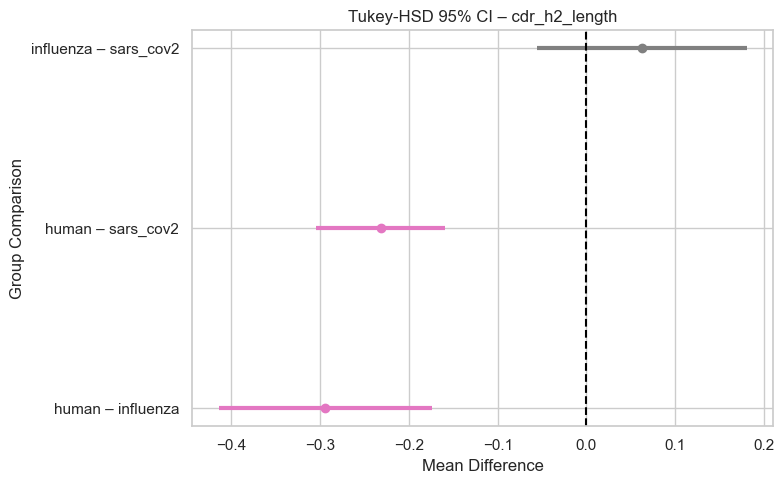

In [94]:

# Tukey-HSD für CDR-H2-Länge
column = "cdr_h2_length"
df_clean = df[[column, "source"]].dropna()

tukey = pairwise_tukeyhsd(endog=df_clean[column], groups=df_clean["source"], alpha=0.05)

# In DataFrame umwandeln
summary_df = pd.DataFrame(data=tukey.summary().data[1:], columns=tukey.summary().data[0])
summary_df["meandiff"] = summary_df["meandiff"].astype(float)
summary_df["lower"] = summary_df["lower"].astype(float)
summary_df["upper"] = summary_df["upper"].astype(float)
summary_df["reject"] = summary_df["reject"].astype(bool)
summary_df["color"] = summary_df["reject"].apply(lambda x: "tab:pink" if x else "gray")

# Plot
plt.figure(figsize=(8, 5))
for i, row in summary_df.iterrows():
    plt.hlines(y=i, xmin=row["lower"], xmax=row["upper"], color=row["color"], lw=3)
    plt.plot(row["meandiff"], i, 'o', color=row["color"])

plt.axvline(x=0, color="black", linestyle="--")
plt.yticks(range(len(summary_df)), [f"{row['group1']} – {row['group2']}" for _, row in summary_df.iterrows()])
plt.title(f"Tukey-HSD 95% CI – {column}")
plt.xlabel("Mean Difference")
plt.ylabel("Group Comparison")
plt.tight_layout()
plt.show()


### Interpretation:
#### - CDR-H2-Länge ist bei SARS-CoV-2-Antikörpern länger als bei human-Antikörpern
#### - CDR-H2-Länge in Influenza länger als bei human
#### => Die mittlere CDR-H2-Länge ist in human-Antikörpern signifikant kürzer als in SARS-CoV-2- und Influenza-Antikörpern.
-----------

## CDR H3 

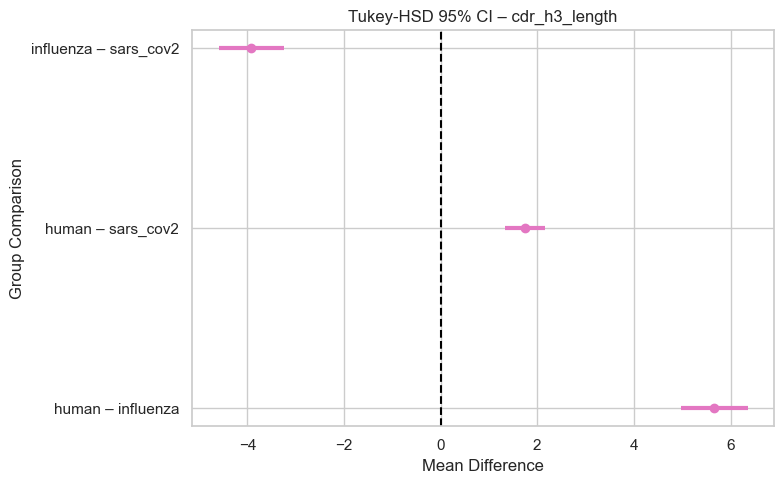

In [95]:

# Tukey-HSD für CDR-H3-Länge
column = "cdr_h3_length"
df_clean = df[[column, "source"]].dropna()

tukey = pairwise_tukeyhsd(endog=df_clean[column], groups=df_clean["source"], alpha=0.05)

# In DataFrame umwandeln
summary_df = pd.DataFrame(data=tukey.summary().data[1:], columns=tukey.summary().data[0])
summary_df["meandiff"] = summary_df["meandiff"].astype(float)
summary_df["lower"] = summary_df["lower"].astype(float)
summary_df["upper"] = summary_df["upper"].astype(float)
summary_df["reject"] = summary_df["reject"].astype(bool)
summary_df["color"] = summary_df["reject"].apply(lambda x: "tab:pink" if x else "gray")

# Plot
plt.figure(figsize=(8, 5))
for i, row in summary_df.iterrows():
    plt.hlines(y=i, xmin=row["lower"], xmax=row["upper"], color=row["color"], lw=3)
    plt.plot(row["meandiff"], i, 'o', color=row["color"])

plt.axvline(x=0, color="black", linestyle="--")
plt.yticks(range(len(summary_df)), [f"{row['group1']} – {row['group2']}" for _, row in summary_df.iterrows()])
plt.title(f"Tukey-HSD 95% CI – {column}")
plt.xlabel("Mean Difference")
plt.ylabel("Group Comparison")
plt.tight_layout()
plt.show()


### Interpretation:
#### - cdr_h3_length ist bei SARS-CoV-2 signifikant länger als bei Influenza
#### - cdr_h3_length ist bei SARS-CoV-2 signifikant kürzer als bei Human
#### - cdr_h3_length ist bei Human signifikant länger als bei Influenza
#### => influenza < sars_cov2 < human
---------